**“Cash Flow and Credit Risk Analysis Using Ledger Data: A Study of Krishna Enterprises”**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Anshika_project_excel.xlsx")
df.head()

,Date,Type,Particulars,Vch_Type,Vch_No,Debit,Credit,Balance
0,2024-04-01,To,Opening Balance,NaN,NaN,102778.2,NaN,102778.2
1,2024-04-03,By,SBI CC,Receipt,28.0,NaN,200000.0,97221.8
2,2024-04-04,To,GST Sale 18%,GST Sale,70.0,274424.0,NaN,177202.2
3,2024-04-06,By,SBI CC,Receipt,59.0,NaN,250000.0,72797.8
4,2024-04-10,To,GST Sale 18%,GST Sale,163.0,343367.0,NaN,270569.2


In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Fill missing values with 0
df['Debit'] = df['Debit'].fillna(0)
df['Credit'] = df['Credit'].fillna(0)

# Remove commas if any and convert to float
df['Debit'] = df['Debit'].astype(float)
df['Credit'] = df['Credit'].astype(float)
df['Balance'] = df['Balance'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         234 non-null    datetime64[ns]
 1   Type         234 non-null    object        
 2   Particulars  234 non-null    object        
 3   Vch_Type     232 non-null    object        
 4   Vch_No       231 non-null    float64       
 5   Debit        234 non-null    float64       
 6   Credit       234 non-null    float64       
 7   Balance      233 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 14.8+ KB


In [ ]:
#creating a transaction column
df['Transaction'] = np.where(df['Debit'] > 0, 'Purchase', 'Payment')
df.head()
#Now we can separate:
#Buying behavior
#Payment behavior
#if debit >0 its purchase
#debit=0 anf credit>0 its payment

,Date,Type,Particulars,Vch_Type,Vch_No,Debit,Credit,Balance,Transaction
0,2024-04-01,To,Opening Balance,NaN,NaN,102778.2,0.0,102778.2,Purchase
1,2024-04-03,By,SBI CC,Receipt,28.0,0.0,200000.0,97221.8,Payment
2,2024-04-04,To,GST Sale 18%,GST Sale,70.0,274424.0,0.0,177202.2,Purchase
3,2024-04-06,By,SBI CC,Receipt,59.0,0.0,250000.0,72797.8,Payment
4,2024-04-10,To,GST Sale 18%,GST Sale,163.0,343367.0,0.0,270569.2,Purchase


In [ ]:
#STEP 5: Add Time Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
#Needed for:
#Monthly trend
#Seasonality analysis



In [ ]:
#STEP 6: Total Purchases vs Payments
total_purchase = df['Debit'].sum()
total_payment = df['Credit'].sum()

print("Total Purchase:", total_purchase)
print("Total Payment:", total_payment)
#What:
#Sum of Debit → total purchases
#Sum of Credit → total payments
#Business Insight:
# If purchase > payment → debt increasing

Total Purchase: 26148448.490000002
Total Payment: 24888891.71


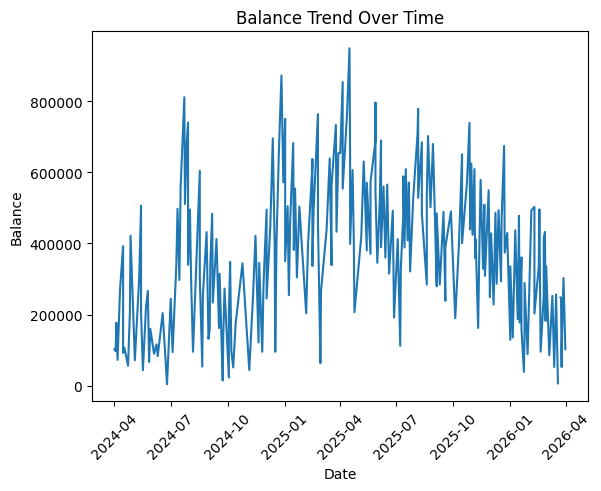

In [ ]:
#Balance Trend Over Time
plt.figure()
plt.plot(df['Date'], df['Balance'])
plt.title("Balance Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Balance")
plt.xticks(rotation=45)
plt.show()
#How debt changes over time
#Insight:
#Rising → risk
#Falling → good payment

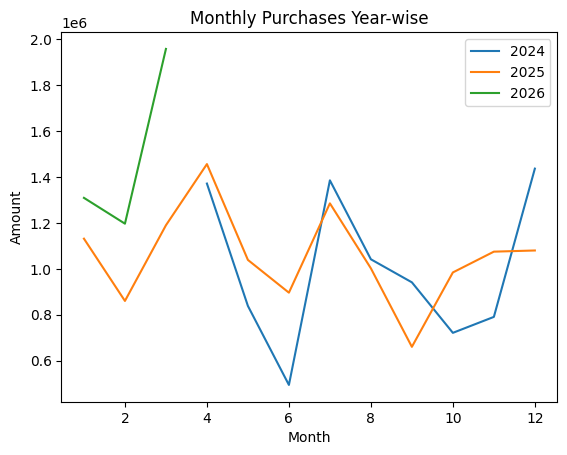

In [ ]:
#STEP 8: Monthly Purchase Trend
monthly_purchase = df.groupby(['Year', 'Month'])['Debit'].sum().reset_index()

plt.figure()

for year in monthly_purchase['Year'].unique():
    data = monthly_purchase[monthly_purchase['Year'] == year]
    plt.plot(data['Month'], data['Debit'], label=str(year))

plt.legend()
plt.title("Monthly Purchases Year-wise")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()
#Groups data by month
#Shows:
# Which months have high purchases
# Insight:
# Demand seasonality (construction periods)

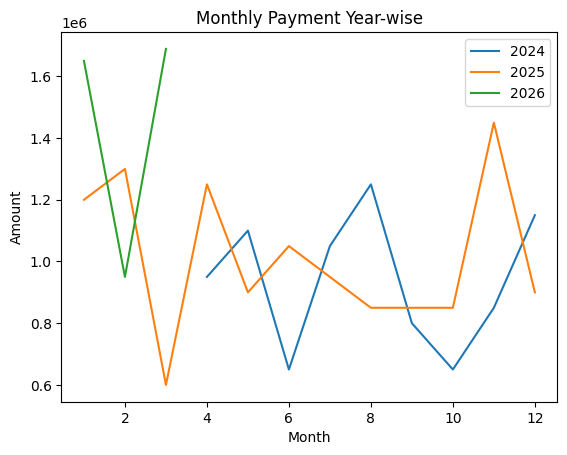

In [ ]:
#STEP 9: Monthly Payments Trend
monthly_payment = df.groupby(['Year', 'Month'])['Credit'].sum().reset_index()
for year in monthly_payment['Year'].unique():
    data = monthly_payment[monthly_payment['Year'] == year]
    plt.plot(data['Month'], data['Credit'], label=str(year))

plt.legend()
plt.title("Monthly Payment Year-wise")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

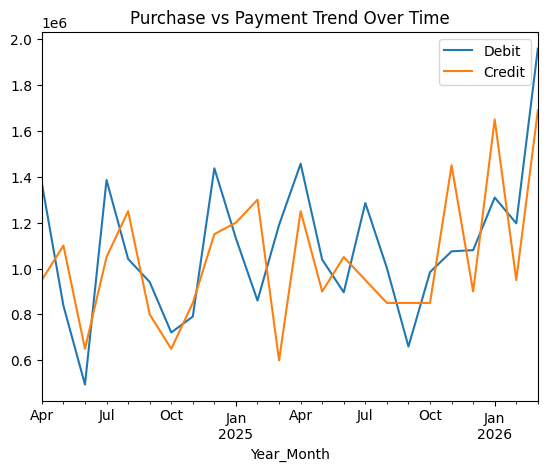

In [ ]:
##STEP 10: Purchase vs Payment Comparison
monthly_payment = df.groupby(['Year', 'Month'])['Credit'].sum().reset_index()

df['Year_Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Year_Month')[['Debit','Credit']].sum()

monthly.plot()
plt.title("Purchase vs Payment Trend Over Time")
plt.show()
#insight:
# Compare with purchases:
#If mismatch → cash flow issue

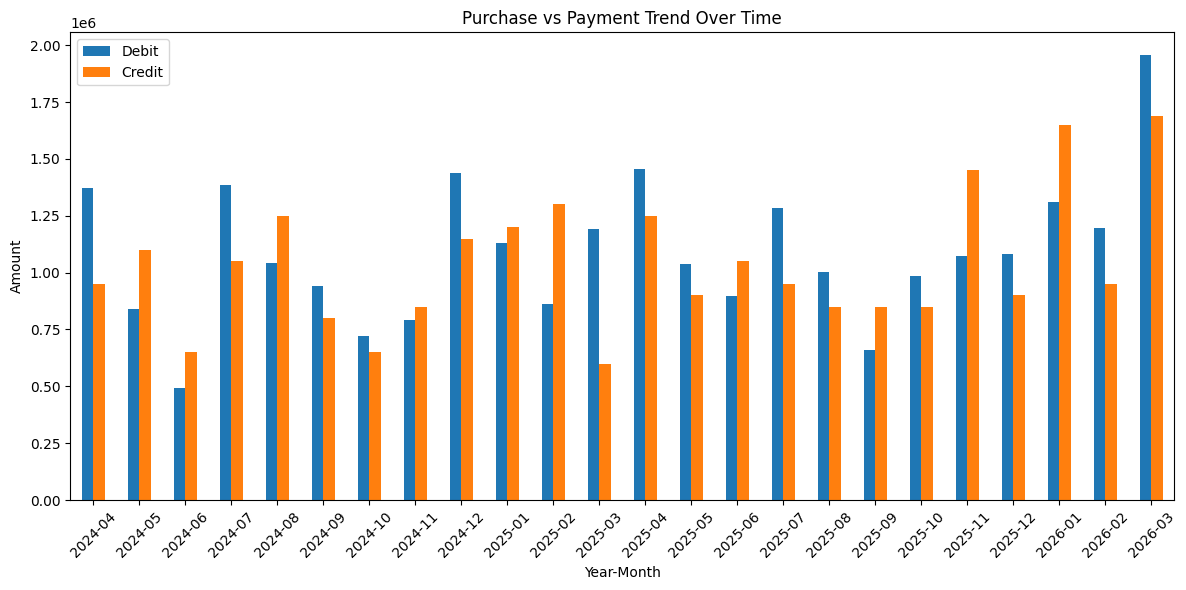

In [ ]:
##STEP 10: Purchase vs Payment Comparison
monthly_payment = df.groupby(['Year', 'Month'])['Credit'].sum().reset_index()

df['Year_Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Year_Month')[['Debit','Credit']].sum()

monthly.plot(kind='bar', figsize=(12,6))
plt.title("Purchase vs Payment Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#insight:
# Compare with purchases:
#If mismatch → cash flow issue

In [ ]:
#STEP 11: Credit Delay Analysis (VERY IMPORTANT)
df = df.sort_values('Date')

df['Cumulative_Purchase'] = df['Debit'].cumsum()
df['Cumulative_Payment'] = df['Credit'].cumsum()

df[['Date','Cumulative_Purchase','Cumulative_Payment']].tail()

,Date,Cumulative_Purchase,Cumulative_Payment
229,2026-03-24,25792782.49,24388891.71
230,2026-03-25,25792782.49,24688891.71
231,2026-03-25,25945925.49,24688891.71
232,2026-03-28,26148448.49,24688891.71
233,2026-03-31,26148448.49,24888891.71


#STEP 11: Credit Delay Analysis (VERY IMPORTANT)
What:
Running total
 Insight:

 Gap between lines = outstanding debt

In [ ]:
#STEP 12: Risk Level Detection
high_risk = df[df['Balance'] > 500000]

print("High Risk Periods:")
print(high_risk[['Date','Balance']])


High Risk Periods:
          Date    Balance
13  2024-05-14  506137.20
31  2024-07-17  558110.20
32  2024-07-23  811061.20
33  2024-07-24  511061.20
34  2024-07-27  687011.20
..         ...        ...
181 2025-11-14  578928.29
183 2025-11-20  508961.29
185 2025-11-27  549363.29
194 2025-12-22  674336.29
212 2026-02-09  502991.29

[62 rows x 2 columns]


step 12
What:
Filters when balance > 5 lakh
Business Insight:

These are dangerous periods for supplier

In [ ]:
#STEP 13: Transaction Frequency
transaction_count = df['Transaction'].value_counts()
print(transaction_count)
#shows more purcaheses or more payments


Transaction
Purchase    138
Payment      96
Name: count, dtype: int64


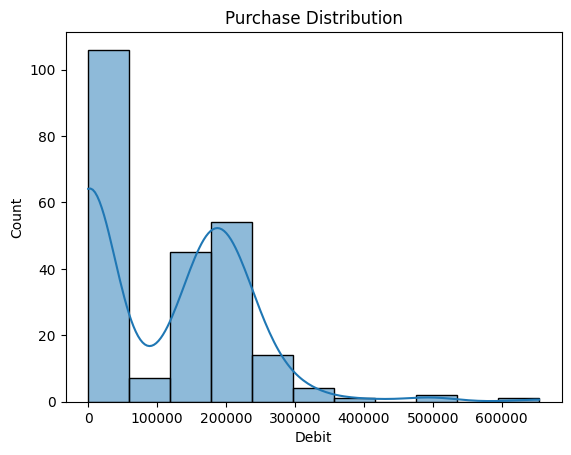

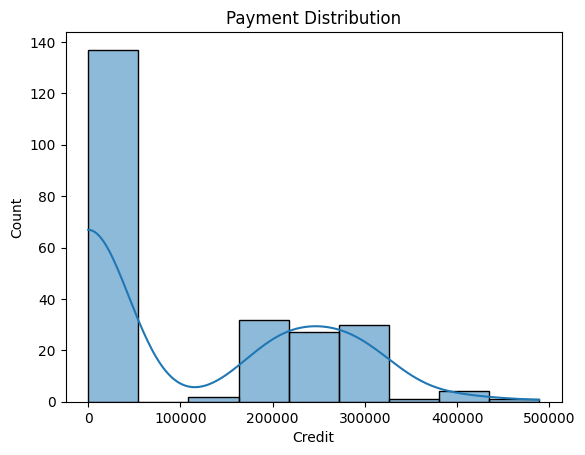

In [ ]:
#STEP 14: Distribution Analysis
plt.figure()
sns.histplot(df['Debit'], kde=True)
plt.title("Purchase Distribution")
plt.show()

plt.figure()
sns.histplot(df['Credit'], kde=True)
plt.title("Payment Distribution")
plt.show()
#Insight:
#Typical transaction size:
#Small frequent?
#Large bulk?

In [ ]:
#STEP 15: Final Business Insight Code
outstanding = total_purchase - total_payment

print("Outstanding Amount:", outstanding)
#net liability of krishna enterprises


Outstanding Amount: 1259556.7800000012


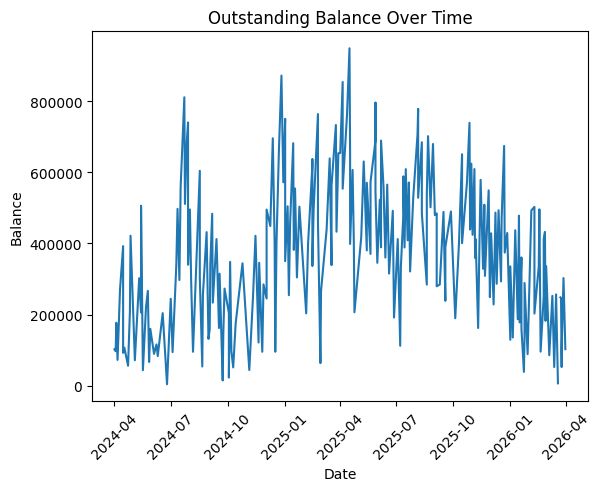

In [ ]:
#STEP 16: Outstanding Trend (MOST IMPORTANT GRAPH)
plt.figure()
plt.plot(df['Date'], df['Balance'])
plt.title("Outstanding Balance Over Time")
plt.xlabel("Date")
plt.ylabel("Balance")
plt.xticks(rotation=45)
plt.show()

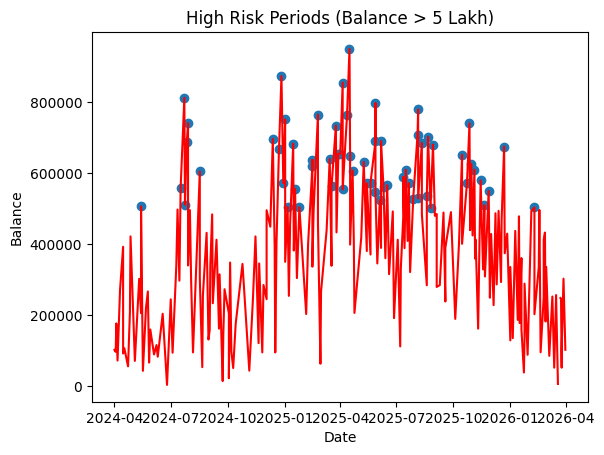

In [ ]:
#STEP 17: High Risk Period Detection
high_risk = df[df['Balance'] > 500000]

plt.figure()
plt.plot(df['Date'], df['Balance'],color='red')
plt.scatter(high_risk['Date'], high_risk['Balance'])
plt.title("High Risk Periods (Balance > 5 Lakh)")
plt.xlabel("Date")
plt.ylabel("Balance")
plt.show()

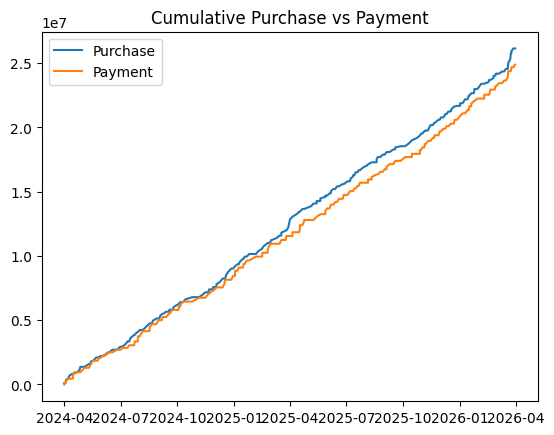

In [ ]:
#STEP 18: Gap Between Purchase & Payment
df['Cumulative_Purchase'] = df['Debit'].cumsum()
df['Cumulative_Payment'] = df['Credit'].cumsum()

plt.figure()
plt.plot(df['Date'], df['Cumulative_Purchase'], label='Purchase')
plt.plot(df['Date'], df['Cumulative_Payment'], label='Payment')
plt.legend()
plt.title("Cumulative Purchase vs Payment")
plt.show()

#step18
What:
Running totals
 Insight:

 Gap = total outstanding credit


 “A persistent gap indicates delayed payment behavior.”

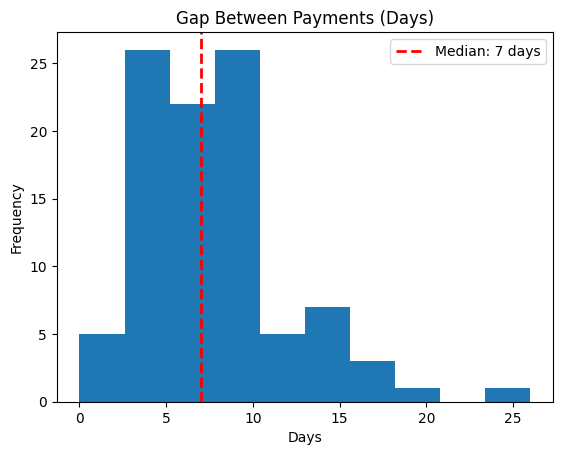

In [ ]:
#STEP 19: Payment Behavior Analysis
payment_days = df[df['Credit'] > 0]['Date'].diff().dt.days.dropna()

plt.figure()
plt.hist(payment_days)
plt.title("Gap Between Payments (Days)")
plt.xlabel("Days")
plt.ylabel("Frequency")

# Calculate and plot the median
median_payment_days = payment_days.median()
plt.axvline(median_payment_days, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_payment_days:.0f} days')
plt.legend()

plt.show()

#step:19
What:
Time gap between payments
 Insight:

 Regular vs irregular payments

“Payments are irregular, indicating lack of structured credit policy.”

In [ ]:
#STEP 20: Average Transaction Size
avg_purchase = df[df['Debit'] > 0]['Debit'].mean()
avg_payment = df[df['Credit'] > 0]['Credit'].mean()

print("Average Purchase:", avg_purchase)
print("Average Payment:", avg_payment)
#Compare:

#Big purchases vs small payments?

Average Purchase: 189481.51079710145
Average Payment: 256586.51247422682


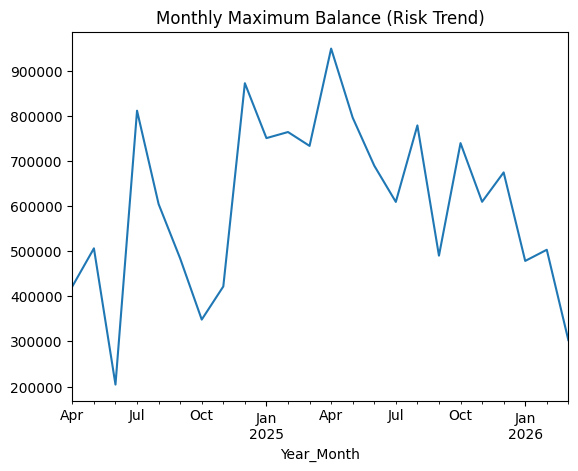

In [ ]:
#STEP 21: Monthly Risk Trend
df['Year_Month'] = df['Date'].dt.to_period('M')

monthly_balance = df.groupby('Year_Month')['Balance'].max()

plt.figure()
monthly_balance.plot()
plt.title("Monthly Maximum Balance (Risk Trend)")
plt.show()
# Insight:

#Identify risky months

In [ ]:
#STEP 4 — Create Year-Month Column
df['YearMonth'] = df['Date'].dt.to_period('M')

In [ ]:
#STEP 5 — Monthly Outstanding Balance
monthly_balance = df.groupby('YearMonth')['Balance'].last().reset_index()

In [ ]:
#STEP 6 — Convert Period to String
monthly_balance['YearMonth'] = monthly_balance['YearMonth'].astype(str)

In [ ]:
#STEP 7 — Create Time Index
monthly_balance['Month_Index'] = range(len(monthly_balance))

In [ ]:
#STEP 8 — Define X and Y
X = monthly_balance[['Month_Index']]
y = monthly_balance['Balance']

In [ ]:
from sklearn.linear_model import LinearRegression

#STEP 9 — Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#STEP 10 — Predict Next 6 Months
future_index = pd.DataFrame({
    'Month_Index': range(len(monthly_balance), len(monthly_balance)+6)
})

future_predictions = model.predict(future_index)

In [ ]:
#STEP 11 — Create Future Month Labels
future_months = pd.period_range(
    start=pd.Period(monthly_balance['YearMonth'].iloc[-1]),
    periods=7,
    freq='M'
)[1:]

In [ ]:
#STEP 12 — Create Forecast DataFrame
forecast_df = pd.DataFrame({
    'Future_Month': future_months.astype(str),
    'Predicted_Balance': future_predictions
})

print(forecast_df)

  Future_Month  Predicted_Balance
0      2026-04      386052.771957
1      2026-05      390181.584113
2      2026-06      394310.396270
3      2026-07      398439.208426
4      2026-08      402568.020583
5      2026-09      406696.832739


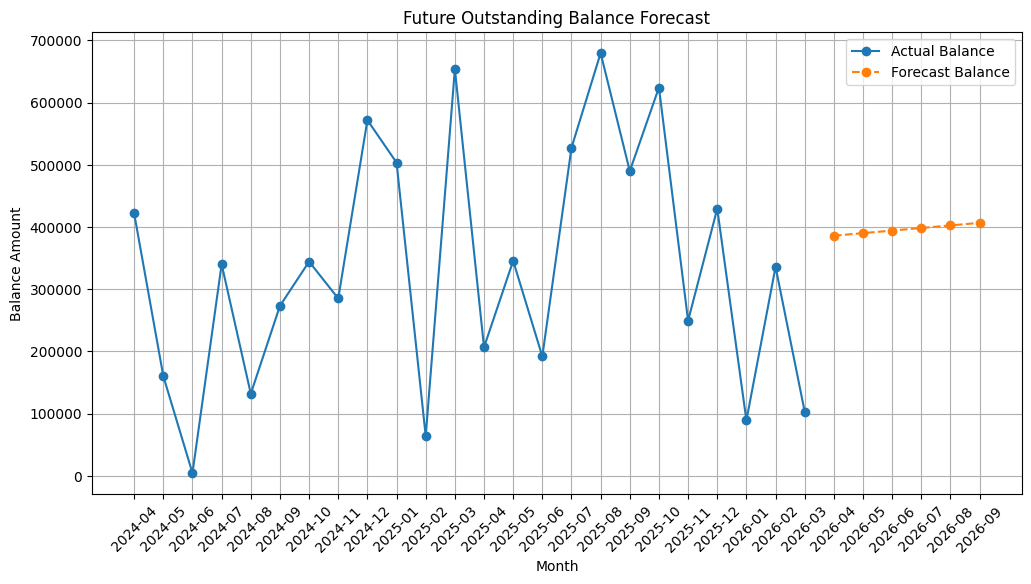

In [ ]:
#STEP 13 — Plot Forecast
plt.figure(figsize=(12,6))

# Actual balance
plt.plot(monthly_balance['YearMonth'],
         monthly_balance['Balance'],
         marker='o',
         label='Actual Balance')

# Forecast balance
plt.plot(forecast_df['Future_Month'],
         forecast_df['Predicted_Balance'],
         marker='o',
         linestyle='dashed',
         label='Forecast Balance')

plt.xticks(rotation=45)
plt.title('Future Outstanding Balance Forecast')
plt.xlabel('Month')
plt.ylabel('Balance Amount')
plt.legend()
plt.grid(True)

plt.show()

WHAT THIS GRAPH SHOWS

The graph compares:

Historical outstanding balance
Future predicted balance

If forecast line increases:
→ Outstanding dues may rise
→ Higher credit risk

If forecast line decreases:
→ Payment stability improving

In [ ]:
#sTEP 14 — Risk Classification


def risk_level(balance):

    if balance > 700000:
        return "High Risk"

    elif balance > 300000:
        return "Medium Risk"

    else:
        return "Low Risk"

In [ ]:
forecast_df['Risk_Level'] = forecast_df['Predicted_Balance'].apply(risk_level)

print(forecast_df)

  Future_Month  Predicted_Balance   Risk_Level
0      2026-04      386052.771957  Medium Risk
1      2026-05      390181.584113  Medium Risk
2      2026-06      394310.396270  Medium Risk
3      2026-07      398439.208426  Medium Risk
4      2026-08      402568.020583  Medium Risk
5      2026-09      406696.832739  Medium Risk


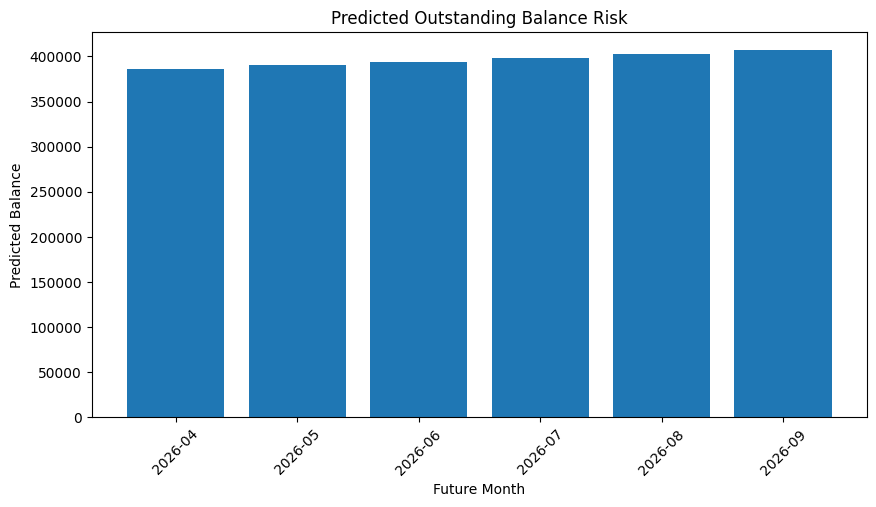

In [ ]:
#STEP 15 — Risk Visualization
plt.figure(figsize=(10,5))

plt.bar(forecast_df['Future_Month'],
        forecast_df['Predicted_Balance'])

plt.xticks(rotation=45)

plt.title('Predicted Outstanding Balance Risk')
plt.xlabel('Future Month')
plt.ylabel('Predicted Balance')

plt.show()

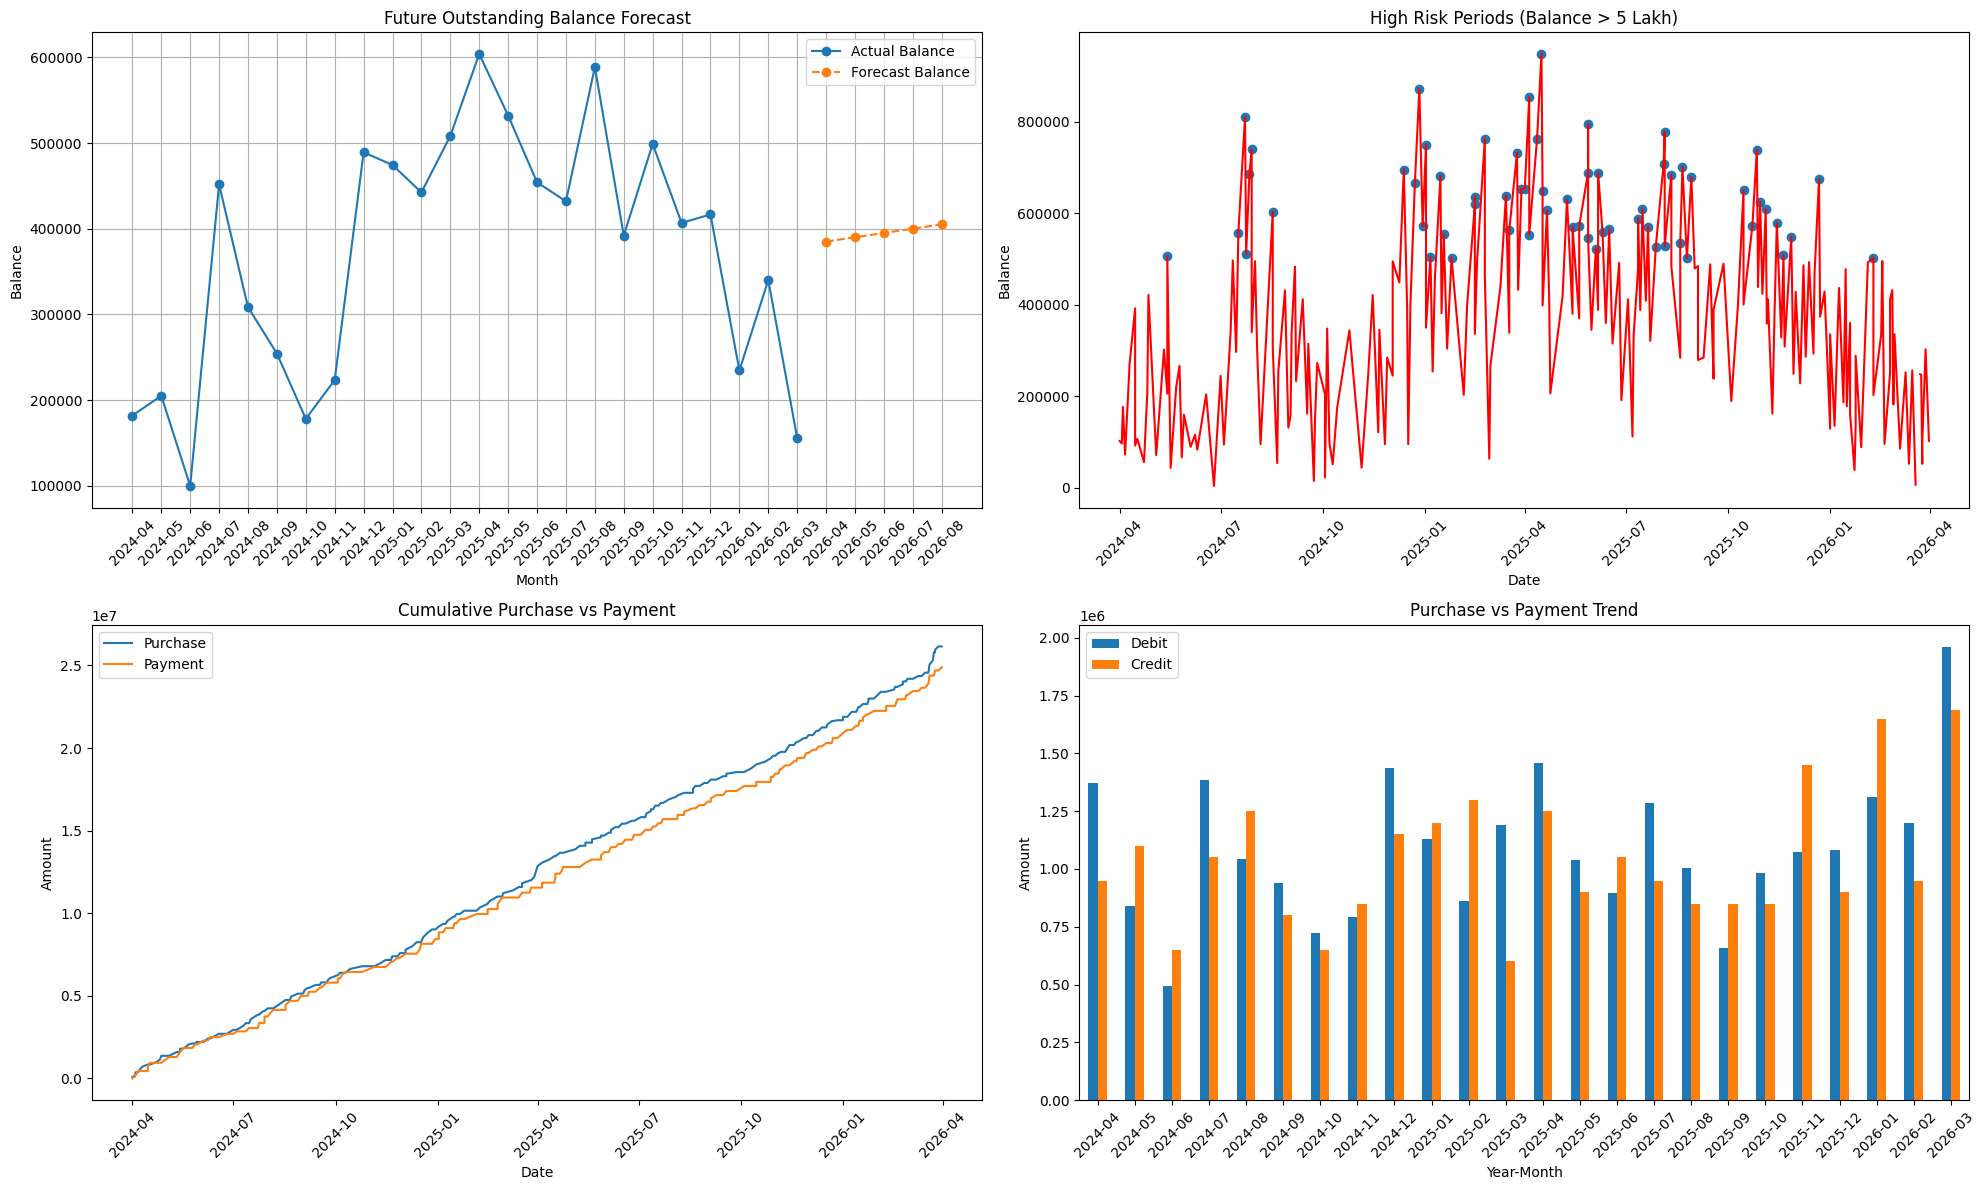

In [ ]:
# ================================
# KRISHNA ENTERPRISES DASHBOARD
# ================================

# STEP 1: IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


monthly_balance = df.groupby('Year_Month')['Balance'].mean().reset_index()
# Convert 'Year_Month' to string for plotting
monthly_balance['Year_Month'] = monthly_balance['Year_Month'].astype(str)

# ================================
# STEP 5: FORECAST DATA
# ================================

future_months = ['2026-04','2026-05','2026-06','2026-07','2026-08']

predicted_balance = [
    385000,
    390000,
    395000,
    400000,
    405000
]

forecast_df = pd.DataFrame({
    'Future_Month': future_months,
    'Predicted_Balance': predicted_balance
})

# ================================
# STEP 6: HIGH RISK DATA
# ================================

high_risk = df[df['Balance'] > 500000]

# ================================
# STEP 7: CUMULATIVE VALUES
# ================================

df['Cumulative_Purchase'] = df['Debit'].cumsum()
df['Cumulative_Payment'] = df['Credit'].cumsum()

# ================================
# STEP 8: MONTHLY PURCHASE VS PAYMENT
# ================================

monthly = df.groupby('Year_Month')[['Debit','Credit']].sum()

# ================================
# STEP 9: CREATE DASHBOARD
# ================================

fig, axes = plt.subplots(2, 2, figsize=(20,12))

# ======================================================
# GRAPH 1: FORECAST GRAPH
# ======================================================

axes[0,0].plot(
    monthly_balance['Year_Month'],
    monthly_balance['Balance'],
    marker='o',
    label='Actual Balance'
)

axes[0,0].plot(
    forecast_df['Future_Month'],
    forecast_df['Predicted_Balance'],
    marker='o',
    linestyle='dashed',
    label='Forecast Balance'
)

axes[0,0].set_title('Future Outstanding Balance Forecast')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Balance')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()
axes[0,0].grid(True)

# ======================================================
# GRAPH 2: HIGH RISK PERIODS
# ======================================================

axes[0,1].plot(df['Date'], df['Balance'], color='red')

axes[0,1].scatter(
    high_risk['Date'],
    high_risk['Balance']
)

axes[0,1].set_title('High Risk Periods (Balance > 5 Lakh)')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Balance')
axes[0,1].tick_params(axis='x', rotation=45)

# ======================================================
# GRAPH 3: CUMULATIVE PURCHASE VS PAYMENT
# ======================================================

axes[1,0].plot(
    df['Date'],
    df['Cumulative_Purchase'],
    label='Purchase'
)

axes[1,0].plot(
    df['Date'],
    df['Cumulative_Payment'],
    label='Payment'
)

axes[1,0].set_title('Cumulative Purchase vs Payment')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Amount')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=45)

# ======================================================
# GRAPH 4: PURCHASE VS PAYMENT BAR CHART
# ======================================================

monthly.plot(
    kind='bar',
    ax=axes[1,1]
)

axes[1,1].set_title('Purchase vs Payment Trend')
axes[1,1].set_xlabel('Year-Month')
axes[1,1].set_ylabel('Amount')
axes[1,1].tick_params(axis='x', rotation=45)

# ================================
# FINAL DASHBOARD SETTINGS
# ================================

plt.tight_layout()
plt.show()